### MLP- 3 - Home A, B, & C

     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   340   341   338   288   289   289   288   292   290   288  ...    805   
1  1353  1380  1388  1276  1258  1253  1245  1248  1269  1261  ...   1310   
2   795   892   831   801   291   342   362   333   343   359  ...    561   
3   435   582   571   559   564   565   567   561   562   570  ...   5733   
4   268   267   266   266   267   268   266   267   267   266  ...   5652   

   M1432  M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    842    819    818    782    833    930    818    850      3  
1   1382   1354   1284   1402   1211   1150   1162   1167      5  
2    509    505    528    535    574    384    378    403      0  
3   5130   5114   5148   5158   5180   5259   5196    679      4  
4   5662   5622   5620   5604   5615   5619   5601   5608      0  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  319  304  303  292  302  3

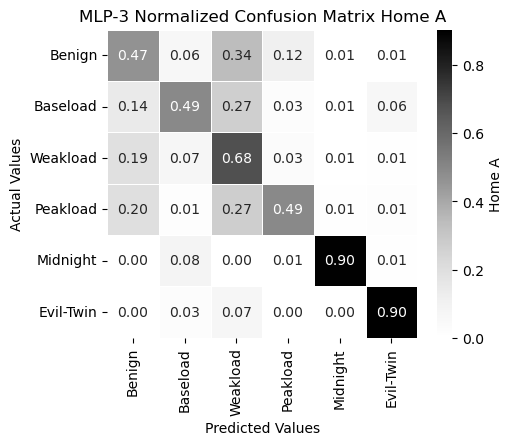

Accuracy Score: 0.3471264367816092
              precision    recall  f1-score   support

           0       0.47      0.47      0.47       146
           1       0.66      0.49      0.56       146
           2       0.42      0.68      0.52       146
           3       0.72      0.49      0.58       140
           4       0.97      0.90      0.93       146
           5       0.89      0.90      0.90       146

    accuracy                           0.66       870
   macro avg       0.69      0.66      0.66       870
weighted avg       0.69      0.66      0.66       870

AUC Score: 0.609062530408364


<Figure size 640x480 with 0 Axes>

In [2]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from zmq.constants import MULTICAST_LOOP
import multiprocessing
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

# Normalise the training data
X_train_norm = X_train / 5000.0
X_test_norm = X_test / 5000.0

#instantiate the model
# MLP-3
mlp_3 = MLPClassifier(random_state=1, hidden_layer_sizes=(720), max_iter=500)

# fit our data
mlp_3.fit(X_train_norm, y_train)

mlp_3.score(X_test_norm, y_test)

# Use Model to get prediction
y_predmlp = mlp_3.predict(X_test_norm)
y_predmlp[:5]

# Confusion matrix
cm = confusion_matrix(y_test, y_predmlp, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Greys', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home A'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('MLP-3 Normalized Confusion Matrix Home A')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeA_mlp-3_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

# accuracy_score(y_test, y_pred_gb)
accuracy_score(y_test, y_predmlp)

# Accuracy score using built in scoring method
accuracy_score = mlp_3.score(X_test, y_test)
# accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_predmlp))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_predmlp_prob = mlp_3.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_predmlp_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")


### MLP-3 Home B

     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   526   481   454   450   447   438   449   450   449   441  ...   2066   
1   394   397   273   293   291   275   275   272   274   276  ...   4128   
2   681   445   457   459   459   458   454   401   402   404  ...    905   
3  3256  3378  3494  3339  3380  3435  3333  3383  3329  3455  ...   1202   
4   605   595   600   604   592   594   607   591   588   469  ...    601   

   M1432  M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0   2077   2081   2085   2085   2085   2088   2091   2087      4  
1    412    437    435    435    437    437    435    441      3  
2    997    868   2414   2651   2671   2699   2796   2781      1  
3   1225   1205   1149   1187   1156   1142   1154   1292      5  
4    744    737    732    737    730    734    681    652      1  

[5 rows x 1441 columns]
     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   319   352   345   336   352  

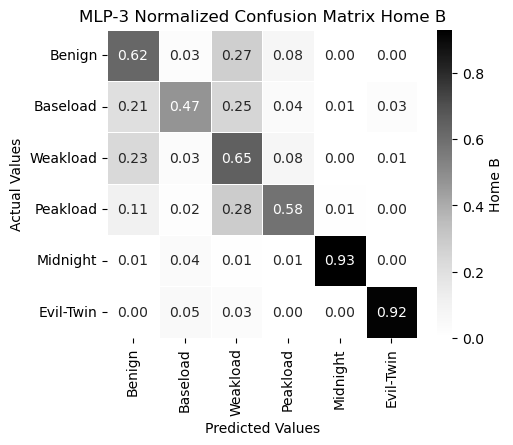

Accuracy Score: 0.3383720930232558
              precision    recall  f1-score   support

           0       0.54      0.62      0.58       146
           1       0.74      0.47      0.58       146
           2       0.44      0.65      0.53       146
           3       0.72      0.58      0.65       130
           4       0.99      0.93      0.96       146
           5       0.96      0.92      0.94       146

    accuracy                           0.70       860
   macro avg       0.73      0.70      0.70       860
weighted avg       0.73      0.70      0.71       860

AUC Score: 0.6039912768760473


<Figure size 640x480 with 0 Axes>

In [5]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from zmq.constants import MULTICAST_LOOP
import multiprocessing
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

# Normalise the training data
X_train_norm = X_train / 5000.0
X_test_norm = X_test / 5000.0

#instantiate the model
# MLP-3
mlp_3 = MLPClassifier(random_state=1, hidden_layer_sizes=(720), max_iter=500)

# fit our data
mlp_3.fit(X_train_norm, y_train)

mlp_3.score(X_test_norm, y_test)

# Use Model to get prediction
y_predmlp = mlp_3.predict(X_test_norm)
y_predmlp[:5]

# Confusion matrix
cm = confusion_matrix(y_test, y_predmlp, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Greys', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home B'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('MLP-3 Normalized Confusion Matrix Home B')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeB_mlp-3_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

# accuracy_score(y_test, y_pred_gb)
accuracy_score(y_test, y_predmlp)

# Accuracy score using built in scoring method
accuracy_score = mlp_3.score(X_test, y_test)
# accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_predmlp))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_predmlp_prob = mlp_3.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_predmlp_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")


### MLP-3 Home C

    M0   M1   M2   M3   M4   M5   M6   M7   M8    M9  ...  M1431  M1432  \
0  368  366  362  361  360  358  357  238  236   234  ...    231    229   
1  629  553  553  547  554  619  565  561  553   540  ...   1065    742   
2  925  893  880  873  869  850  864  865  862  1008  ...    833    854   
3  302  316  293  327  291  277  275  224  225   223  ...    481    487   
4  519  504  488  488  488  487  486  488  490   489  ...    352    345   

   M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    234    230    228    218    229    229    228      0  
1    757    734    724    731    731    733    630      5  
2    837    840    849    725    735    724    723      5  
3    487    490    214    274    415    457    476      0  
4    341    342    338    340    341    336    335      4  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  461  459  462  465  459  316  326  328  326  328  ...    437    445    455   
1 

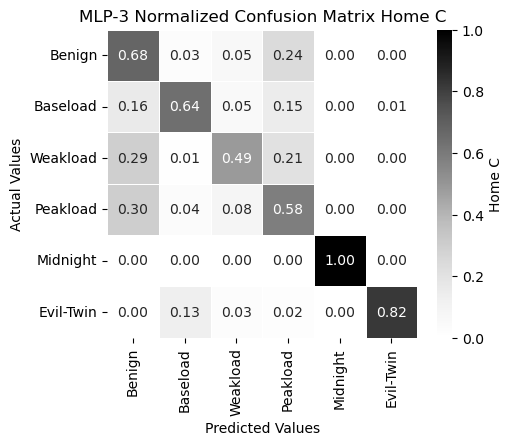

Accuracy Score: 0.2665847665847666
              precision    recall  f1-score   support

           0       0.52      0.68      0.59       146
           1       0.77      0.64      0.70       146
           2       0.73      0.49      0.58       146
           3       0.35      0.58      0.44        84
           4       1.00      1.00      1.00       146
           5       0.99      0.82      0.90       146

    accuracy                           0.71       814
   macro avg       0.73      0.70      0.70       814
weighted avg       0.76      0.71      0.72       814

AUC Score: 0.5608737026924624


<Figure size 640x480 with 0 Axes>

In [6]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from zmq.constants import MULTICAST_LOOP
import multiprocessing
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_C_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_C_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

# Normalise the training data
X_train_norm = X_train / 5000.0
X_test_norm = X_test / 5000.0

#instantiate the model
# MLP-3
mlp_3 = MLPClassifier(random_state=1, hidden_layer_sizes=(720), max_iter=500)

# fit our data
mlp_3.fit(X_train_norm, y_train)

mlp_3.score(X_test_norm, y_test)

# Use Model to get prediction
y_predmlp = mlp_3.predict(X_test_norm)
y_predmlp[:5]

# Confusion matrix
cm = confusion_matrix(y_test, y_predmlp, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Greys', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home C'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('MLP-3 Normalized Confusion Matrix Home C')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeC_mlp-3_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

# accuracy_score(y_test, y_pred_gb)
accuracy_score(y_test, y_predmlp)

# Accuracy score using built in scoring method
accuracy_score = mlp_3.score(X_test, y_test)
# accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_predmlp))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_predmlp_prob = mlp_3.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_predmlp_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")


### MLP-4 Home A

     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   340   341   338   288   289   289   288   292   290   288  ...    805   
1  1353  1380  1388  1276  1258  1253  1245  1248  1269  1261  ...   1310   
2   795   892   831   801   291   342   362   333   343   359  ...    561   
3   435   582   571   559   564   565   567   561   562   570  ...   5733   
4   268   267   266   266   267   268   266   267   267   266  ...   5652   

   M1432  M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    842    819    818    782    833    930    818    850      3  
1   1382   1354   1284   1402   1211   1150   1162   1167      5  
2    509    505    528    535    574    384    378    403      0  
3   5130   5114   5148   5158   5180   5259   5196    679      4  
4   5662   5622   5620   5604   5615   5619   5601   5608      0  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  319  304  303  292  302  3

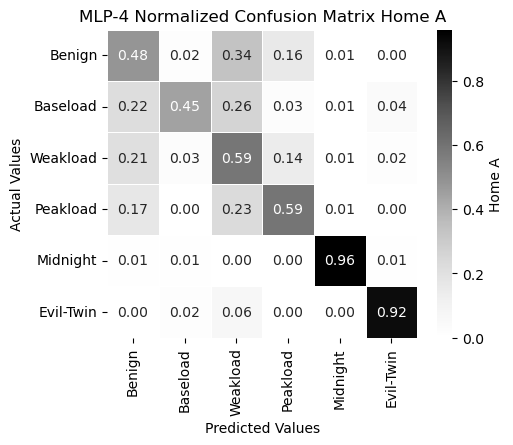

Accuracy Score: 0.36666666666666664
              precision    recall  f1-score   support

           0       0.44      0.48      0.46       146
           1       0.84      0.45      0.58       146
           2       0.40      0.59      0.48       146
           3       0.63      0.59      0.61       140
           4       0.97      0.96      0.97       146
           5       0.92      0.92      0.92       146

    accuracy                           0.66       870
   macro avg       0.70      0.66      0.67       870
weighted avg       0.70      0.66      0.67       870

AUC Score: 0.6205306597398667


<Figure size 640x480 with 0 Axes>

In [4]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from zmq.constants import MULTICAST_LOOP
import multiprocessing
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

# Normalise the training data
X_train_norm = X_train / 5000.0
X_test_norm = X_test / 5000.0

#instantiate the model
# MLP-4
mlp_4 = MLPClassifier(random_state=1, hidden_layer_sizes=(720,200), max_iter=500)

# fit our data
mlp_4.fit(X_train_norm, y_train)

mlp_4.score(X_test_norm, y_test)

# Use Model to get prediction
y_predmlp_4 = mlp_4.predict(X_test_norm)
y_predmlp_4[:5]

# Confusion matrix
cm = confusion_matrix(y_test, y_predmlp_4, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Greys', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home A'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('MLP-4 Normalized Confusion Matrix Home A')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeA_mlp-4_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

# accuracy_score(y_test, y_pred_gb)
accuracy_score(y_test, y_predmlp_4)

# Accuracy score using built in scoring method
accuracy_score = mlp_4.score(X_test, y_test)
# accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_predmlp_4))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_predmlp_4_prob = mlp_4.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_predmlp_4_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")

### MLP-4 Home B

     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   526   481   454   450   447   438   449   450   449   441  ...   2066   
1   394   397   273   293   291   275   275   272   274   276  ...   4128   
2   681   445   457   459   459   458   454   401   402   404  ...    905   
3  3256  3378  3494  3339  3380  3435  3333  3383  3329  3455  ...   1202   
4   605   595   600   604   592   594   607   591   588   469  ...    601   

   M1432  M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0   2077   2081   2085   2085   2085   2088   2091   2087      4  
1    412    437    435    435    437    437    435    441      3  
2    997    868   2414   2651   2671   2699   2796   2781      1  
3   1225   1205   1149   1187   1156   1142   1154   1292      5  
4    744    737    732    737    730    734    681    652      1  

[5 rows x 1441 columns]
     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   319   352   345   336   352  

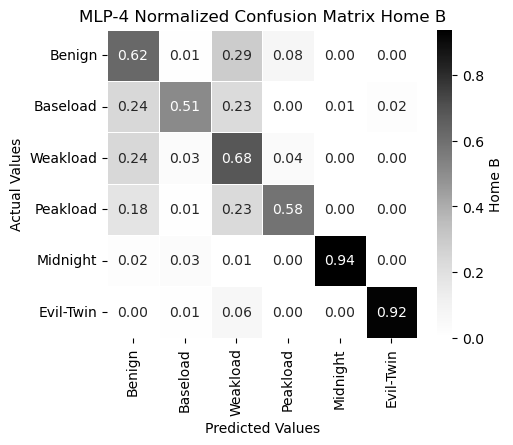

Accuracy Score: 0.3686046511627907
              precision    recall  f1-score   support

           0       0.49      0.62      0.55       146
           1       0.83      0.51      0.63       146
           2       0.47      0.68      0.55       146
           3       0.82      0.58      0.68       130
           4       0.99      0.94      0.96       146
           5       0.98      0.92      0.95       146

    accuracy                           0.71       860
   macro avg       0.76      0.71      0.72       860
weighted avg       0.76      0.71      0.72       860

AUC Score: 0.6188134298327691


<Figure size 640x480 with 0 Axes>

In [7]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from zmq.constants import MULTICAST_LOOP
import multiprocessing
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

# Normalise the training data
X_train_norm = X_train / 5000.0
X_test_norm = X_test / 5000.0

#instantiate the model
# MLP-4
mlp_4 = MLPClassifier(random_state=1, hidden_layer_sizes=(720,200), max_iter=500)

# fit our data
mlp_4.fit(X_train_norm, y_train)

mlp_4.score(X_test_norm, y_test)

# Use Model to get prediction
y_predmlp_4 = mlp_4.predict(X_test_norm)
y_predmlp_4[:5]

# Confusion matrix
cm = confusion_matrix(y_test, y_predmlp_4, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Greys', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home B'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('MLP-4 Normalized Confusion Matrix Home B')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeB_mlp-4_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

# accuracy_score(y_test, y_pred_gb)
accuracy_score(y_test, y_predmlp_4)

# Accuracy score using built in scoring method
accuracy_score = mlp_4.score(X_test, y_test)
# accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_predmlp_4))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_predmlp_4_prob = mlp_4.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_predmlp_4_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")

### MLP-4 Home C

    M0   M1   M2   M3   M4   M5   M6   M7   M8    M9  ...  M1431  M1432  \
0  368  366  362  361  360  358  357  238  236   234  ...    231    229   
1  629  553  553  547  554  619  565  561  553   540  ...   1065    742   
2  925  893  880  873  869  850  864  865  862  1008  ...    833    854   
3  302  316  293  327  291  277  275  224  225   223  ...    481    487   
4  519  504  488  488  488  487  486  488  490   489  ...    352    345   

   M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    234    230    228    218    229    229    228      0  
1    757    734    724    731    731    733    630      5  
2    837    840    849    725    735    724    723      5  
3    487    490    214    274    415    457    476      0  
4    341    342    338    340    341    336    335      4  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  461  459  462  465  459  316  326  328  326  328  ...    437    445    455   
1 

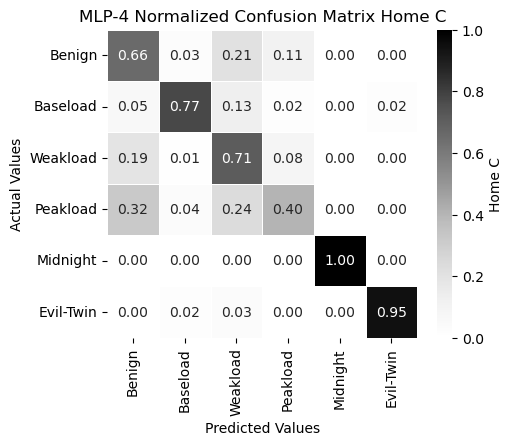

Accuracy Score: 0.3488943488943489
              precision    recall  f1-score   support

           0       0.60      0.66      0.63       146
           1       0.90      0.77      0.83       146
           2       0.58      0.71      0.64       146
           3       0.52      0.40      0.46        84
           4       1.00      1.00      1.00       146
           5       0.98      0.95      0.96       146

    accuracy                           0.78       814
   macro avg       0.77      0.75      0.75       814
weighted avg       0.78      0.78      0.78       814

AUC Score: 0.6022366796088189


<Figure size 640x480 with 0 Axes>

In [8]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from zmq.constants import MULTICAST_LOOP
import multiprocessing
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_C_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_C_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

# Normalise the training data
X_train_norm = X_train / 5000.0
X_test_norm = X_test / 5000.0

#instantiate the model
# MLP-4
mlp_4 = MLPClassifier(random_state=1, hidden_layer_sizes=(720,200), max_iter=500)

# fit our data
mlp_4.fit(X_train_norm, y_train)

mlp_4.score(X_test_norm, y_test)

# Use Model to get prediction
y_predmlp_4 = mlp_4.predict(X_test_norm)
y_predmlp_4[:5]

# Confusion matrix
cm = confusion_matrix(y_test, y_predmlp_4, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Greys', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home C'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('MLP-4 Normalized Confusion Matrix Home C')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeC_mlp-4_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

# accuracy_score(y_test, y_pred_gb)
accuracy_score(y_test, y_predmlp_4)

# Accuracy score using built in scoring method
accuracy_score = mlp_4.score(X_test, y_test)
# accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_predmlp_4))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_predmlp_4_prob = mlp_4.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_predmlp_4_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")